In [209]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
import statistics
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, RocCurveDisplay, auc
sns.set()

In [210]:
df = pd.read_csv('./data/MAGIC Gamma Telescope.csv')
df.dropna()
y = np.array([1 if x == 'g' else 0 for x in df['class']])
X = df.drop(columns=['class'])





In [ ]:
#sigmoid function to convert outputs into probabilities [0,1]
def sigmoid(z):
    return 1.0 / (1 + np.exp(-z))

In [ ]:
#gradient calculation for logistic regression... including l2 regularization
def gradient(X, theta, y, lam):
    reg_vector = np.array([0 if i == 0 else theta[i] for i in range(len(theta))])
    m = y.size
    return (((X.T @ (sigmoid(X @ theta) - y))/m) + lam/m*(reg_vector))

In [ ]:
def gradient_descent(X, y, n_iterations=100, alpha=0.1, tolerance= 1e-7, lam=0.1):
    #add bias term
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    #initialize theta 
    theta = np.zeros((X_b.shape[1]))
    #actual training loop, first calculates current gradient, if early stopping (i.e. gradient norm < tolerance) break and return current theta
    #else continue updating... added tracking of norm to follow training progress in terminal
    for i in range(n_iterations):
        grad = gradient(X_b, theta, y, lam)
        if np.linalg.norm(grad) < tolerance:
            break
        theta -= alpha * grad
        print(f"Gradient Norm Episode {i}: {np.linalg.norm(grad)}")
    return theta

In [ ]:
# Predicted class based on decision threshold, default is 0.5... meaning function outputs 1 if logit >= 0.5
def prediction(theta, X, threshold=0.5):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return np.array((sigmoid(X_b @ theta) >= threshold), dtype=int)

In [ ]:
#raw logit prediction of model
def prob_prediction(theta, X):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return np.array((sigmoid(X_b @ theta)), dtype=float)

In [ ]:
#Scale features do avoid exploding gradients and split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [225]:

#Training Loop (gradient descent for n iterations with learning rate alpha... this is obviously batch gradient descent)
theta_star = gradient_descent(X_train_scaled, y_train, n_iterations=10000, alpha=0.1, tolerance=1e-8, lam=1.0)

Gradient Norm Episode 0: 0.3575272737939607
Gradient Norm Episode 1: 0.3422850339627491
Gradient Norm Episode 2: 0.32826328260260945
Gradient Norm Episode 3: 0.31536519631393567
Gradient Norm Episode 4: 0.30348081758545337
Gradient Norm Episode 5: 0.2924990844620826
Gradient Norm Episode 6: 0.2823153283848495
Gradient Norm Episode 7: 0.2728351192369968
Gradient Norm Episode 8: 0.26397560505183504
Gradient Norm Episode 9: 0.2556653437678849
Gradient Norm Episode 10: 0.24784334783224984
Gradient Norm Episode 11: 0.24045780390734314
Gradient Norm Episode 12: 0.23346473615319502
Gradient Norm Episode 13: 0.226826752906642
Gradient Norm Episode 14: 0.22051193814646616
Gradient Norm Episode 15: 0.21449290477853483
Gradient Norm Episode 16: 0.20874600376220476
Gradient Norm Episode 17: 0.20325067265710967
Gradient Norm Episode 18: 0.1979889037129833
Gradient Norm Episode 19: 0.19294481178755768
Gradient Norm Episode 20: 0.18810428421940698
Gradient Norm Episode 21: 0.1834546972373926
Gradient

In [226]:
predictions = prediction(theta_star, X_test_scaled)

acc = accuracy_score(y_test, predictions)

f1 = f1_score(y_test, predictions)

rec = recall_score(y_test, predictions)

prec = precision_score(y_test, predictions)

print(f"Accuracy: {acc}\nF1-Score: {f1}\nRecall: {rec}\nPrecision: {prec}")


Accuracy: 0.7839116719242902
F1-Score: 0.844022770398482
Recall: 0.9018653690186537
Precision: 0.7931526390870185


0.8313


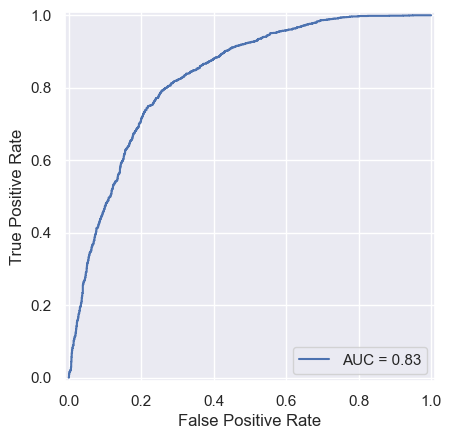

In [ ]:
##ROC-AUC
y_score = prob_prediction(theta_star, X_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)
roc_1 = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc = roc_auc)
roc_1.plot()
print("%.2f" %(roc_auc))